<a href="https://colab.research.google.com/github/SecH0us3/check-quantum-python/blob/main/check_quantum_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit-aer

In [62]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

# We use 3 qubits to keep the visualization clear
qc = QuantumCircuit(3)

# Instead of Hadamard (which is a 50/50 split),
# we apply different rotations to each qubit to get different heights
qc.ry(np.pi/4, 0)  # Qubit 0
qc.ry(np.pi/8, 1)  # Qubit 1
qc.ry(np.pi/2, 2)  # Qubit 2

# Add some entanglement to make the distribution even more complex
qc.cx(0, 1)
qc.cx(1, 2)

# Save the state before measurement
state_before_measurement = Statevector.from_instruction(qc)

print("Circuit created with non-uniform amplitudes.")

Circuit created, state saved in Colab's memory.


Drawing the saved state with different heights...


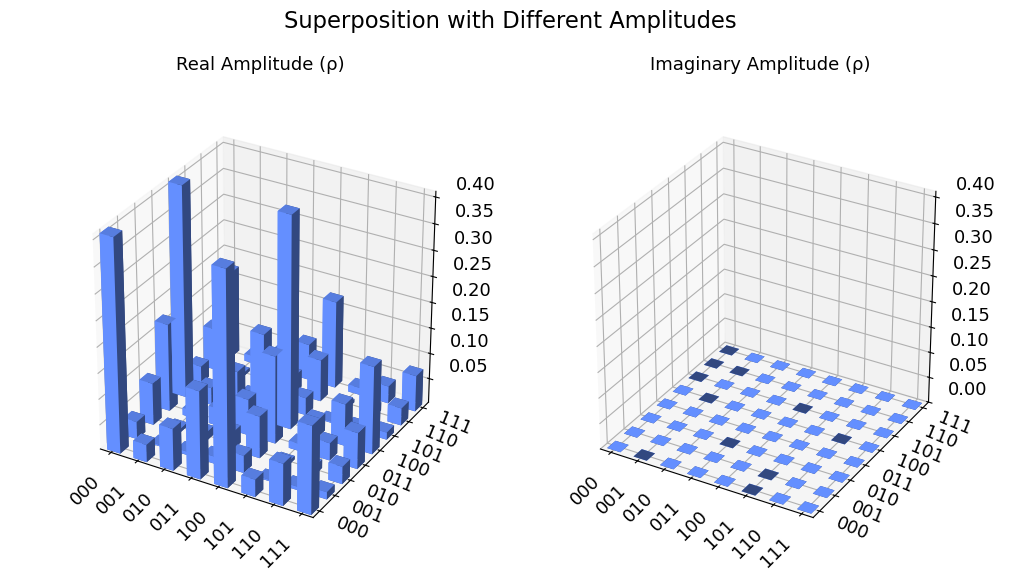

In [5]:
from qiskit.visualization import plot_state_city
from IPython.display import display
import numpy as np

# Ensure the state is defined even if the previous cell wasn't run
try:
    state_to_plot = state_before_measurement
except NameError:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    qc = QuantumCircuit(3)
    qc.ry(np.pi/4, 0)
    qc.ry(np.pi/8, 1)
    qc.ry(np.pi/2, 2)
    qc.cx(0, 1)
    qc.cx(1, 2)
    state_to_plot = Statevector.from_instruction(qc)

print("Drawing the saved state with different heights...")
fig = plot_state_city(state_to_plot, title="Superposition with Different Amplitudes", figsize=(10, 6))
display(fig)

In [9]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
import numpy as np

# Ensure qc is defined
try:
    qc_to_measure = qc
except NameError:
    qc_to_measure = QuantumCircuit(3)
    qc_to_measure.ry(np.pi/4, 0)
    qc_to_measure.ry(np.pi/8, 1)
    qc_to_measure.ry(np.pi/2, 2)
    qc_to_measure.cx(0, 1)
    qc_to_measure.cx(1, 2)

# Add measurements
qc_to_measure.measure_all()

# Running the simulator
simulator = AerSimulator()
result = simulator.run(qc_to_measure, shots=1).result()

# Getting the result
counts = result.get_counts()
binary_string = list(counts.keys())[0]
# Fix: remove spaces from the binary string before conversion
clean_binary_string = binary_string.replace(' ', '')
random_number = int(clean_binary_string, 2)

print(f"The wave function collapsed! Number dropped: {random_number} (binary: {clean_binary_string})")

The wave function collapsed! Number dropped: 1755 (binary: 011011011011)
